In [1]:
# Conditional Edges 조건 분기 - 그래프와 실행 경로를 동적으로 설정 가능
!pip install langgraph

[node_a] counter=1, alphabet=['오늘은 금요일']
[node_a] counter=2, alphabet=['보람찬 한 주']
[node_b] processed = final_processed:['보람찬 한 주']

최종 상태(state) : {'counter': 2, 'alphabet': ['보람찬 한 주'], 'processed': "final_processed:['보람찬 한 주']"}


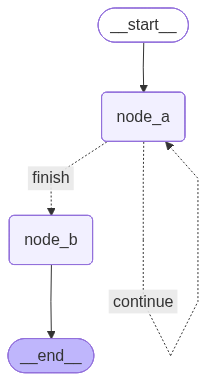

In [4]:
from langgraph import graph
from typing import TypedDict, List
from langgraph.graph import StateGraph, END, START

class State(TypedDict):
  counter:int
  alphabet:List[str]
  processed:str

def node_a(state:State) -> State:
  state["counter"] += 1    # 실행 횟수 누적용

  if state["counter"] == 1:
    state["alphabet"] = ["오늘은 금요일"]
  elif state["counter"] == 2:
    state["alphabet"] = ["보람찬 한 주"]
  else:
    state["alphabet"] = ["ok"]

  print(f"[node_a] counter={state["counter"]}, alphabet={state["alphabet"]}")

  return state

# node_a 수행 후 어디로 갈지 분기 결정 함수
def route_next(state:State) -> str:
  if state["counter"] < 2:
    return "continue"
  else:
    return "finish"

# node_a에서 반복해 처리된 결과를 바탕으로 후 처리를 수행
def node_b(state:State) -> State:
  text = state.get("alphabet", [""][0])
  state["processed"] = f"final_processed:{text}"
  print(f"[node_b] processed = {state['processed']}")
  return state

def build_graph():
  graph = StateGraph(State)

  graph.add_node("node_a", node_a)
  graph.add_node("node_b", node_b)

  graph.set_entry_point("node_a")

  # 분기
  graph.add_conditional_edges(
      "node_a",
      route_next,
      {
          "continue":"node_a",
          "finish":"node_b"
      }
  )

  graph.add_edge("node_b", END)
  return graph.compile()    # runnable 객체 반환


if __name__=="__main__":
  graph = build_graph()

  state:State = {
      "counter":0,
      "alphabet":[],
      "processed":""
  }

  final = graph.invoke(state)

  print(f"\n최종 상태(state) : {final}")

  # 시각화
  try:
    from IPython.display import Image, display
    graph_obj = graph.get_graph()
    png_bytes = graph_obj.draw_mermaid_png()     # Mermaid 기반 png 이미지 얻기
    display(Image(png_bytes))

  except Exception as e:
    print(f"그래프 시각화 실패 : {e}")